<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</center></font>
<center><font size=6>Agentic AI Solutions</center></font>
<center><font size=6>Multi-Agent Systems</center></font>

<center><p float="center">
  <img src="https://images.pexels.com/photos/8204367/pexels-photo-8204367.jpeg" width="640"/>
</p></center>

<center><font size=6>AI Helpdesk Copilot
</center></font>

## **Problem Statement**


### Business Context






A fast-growing B2B SaaS company receives hundreds of inbound customer support tickets daily through email and web forms. Each ticket must be reviewed, categorized, routed to the correct team, and responded to with accurate troubleshooting steps and policy-compliant language. Today, this workflow is largely manual. Support agents read each ticket, decide which queue should handle it, assign a type and priority level, search internal documentation, and draft a first response. This results in slow first response times, inconsistent routing, variable response quality, and limited reuse of institutional knowledge.

Manual triage introduces frequent routing errors, where tickets land in the wrong department and require reassignment, increasing resolution time and operational friction. Drafted responses vary significantly in quality, sometimes omitting required troubleshooting steps or including unsupported claims. Knowledge base articles and SOPs are not systematically grounded in replies, creating risk of hallucinations or policy violations. Furthermore, edits made by senior agents and ticket resolution outcomes are rarely captured in a structured manner, preventing continuous learning and improvement.

Traditional rule-based routing systems rely on keyword matching and static workflows. They lack contextual understanding of nuanced ticket language, cannot reason over ambiguous customer intent, and cannot generate grounded, policy-aware responses. Simple classification models improve routing but do not solve response quality, knowledge grounding, escalation judgment, or auditability requirements. A scalable, intelligent system is required one that integrates predictive classification, retrieval-augmented reasoning, policy validation, and continuous feedback learning within a transparent and auditable architecture.

### Objective

The objective is to build an AI-powered Helpdesk Copilot that automates ticket triage and grounded first-response generation through an agentic workflow.

The system will:

* Accurately classify incoming tickets into correct queue, type, and priority categories using  LLM-assisted reasoning.
* Generate high-quality, grounded first responses using retrieval-augmented generation (RAG) from internal knowledge bases, SOPs, and policy documents, with zero tolerance for hallucinated claims.
* Implement a structured agentic pipeline that performs retrieval, reasoning, evidence validation, uncertainty detection, and escalation when required.
* Validate all generated responses by mapping claims to supporting evidence and enforcing internal compliance policies before delivery.
* Provide explainability by exposing the reasoning trail from retrieval through classification and response drafting, allowing audit and managerial oversight.

The end goal is to reduce manual effort by 80-90%, decrease hallucination-related escalations, improve first response time and customer satisfaction, and establish a continuously learning, policy-compliant support automation system with full transparency and operational scalability.

### Data Description

Customer support ticket dataset collected from a B2B SaaS company’s helpdesk system. The data represents historical inbound tickets along with their verified first responses.

**File Used** (CSV format):

**ticket_data.csv** - Unified ticket dataset

   * **subject** - Short summary line submitted by the customer (email subject or web-form title).
   * **body** - Full ticket description containing the customer’s issue, context, error details, and urgency cues.
   * **answer** - Verified first response provided by the support team (used as ground truth for response generation training and evaluation).
   * **type** - Ticket category (e.g., incident, request, problem, change).
   * **queue** - Assigned department or owning team responsible for handling the ticket.
   * **priority** - Urgency level of the ticket (e.g., High, Medium, Low or P1-P4).
   * **language** - Language of the ticket (used for filtering, preprocessing, or multilingual handling).

## **Solution Architecture**

The solution is built as a **hybrid multi-agent architecture**, combining deterministic workflow control with ReAct-style agents.

1. **Orchestrator Layer**: A deterministic orchestrator manages the overall workflow - **intake → triage → confidence check → response → validation → delivery/escalation**.

2. **Response Agent**: A ReAct-style agent handles response generation and dynamically decides when to use **Drafting, Redrafting, Grounding Check, Policy Check, and RAG** capabilities.

3. **RAG Sub-Agent**: A  ReAct-style agent handles knowledge retrieval by using **Query Formulation, Vector Search, and Sufficiency Check** tools.

4. **Safety & Validation Layer**: Grounding, policy, and evidence-sufficiency checks act as mandatory gates before a response can be delivered.

5. **Human Escalation**: Low-confidence tickets or responses that fail validation are routed to **human review** rather than being automatically delivered.


**Why Multi-Agent Instead of a Single Agent?**

1. **Specialization:** Different agents focus on specific tasks — the Response Agent handles answer generation and validation, while the RAG Sub-Agent specializes in knowledge retrieval.

2. **Better Control & Reliability:** The deterministic Orchestrator controls routing, confidence checks, validation, and escalation, ensuring responses meet the required thresholds before delivery.

3. **Modularity & Maintainability:** Each component can be independently monitored, debugged, and improved without changing the entire system.

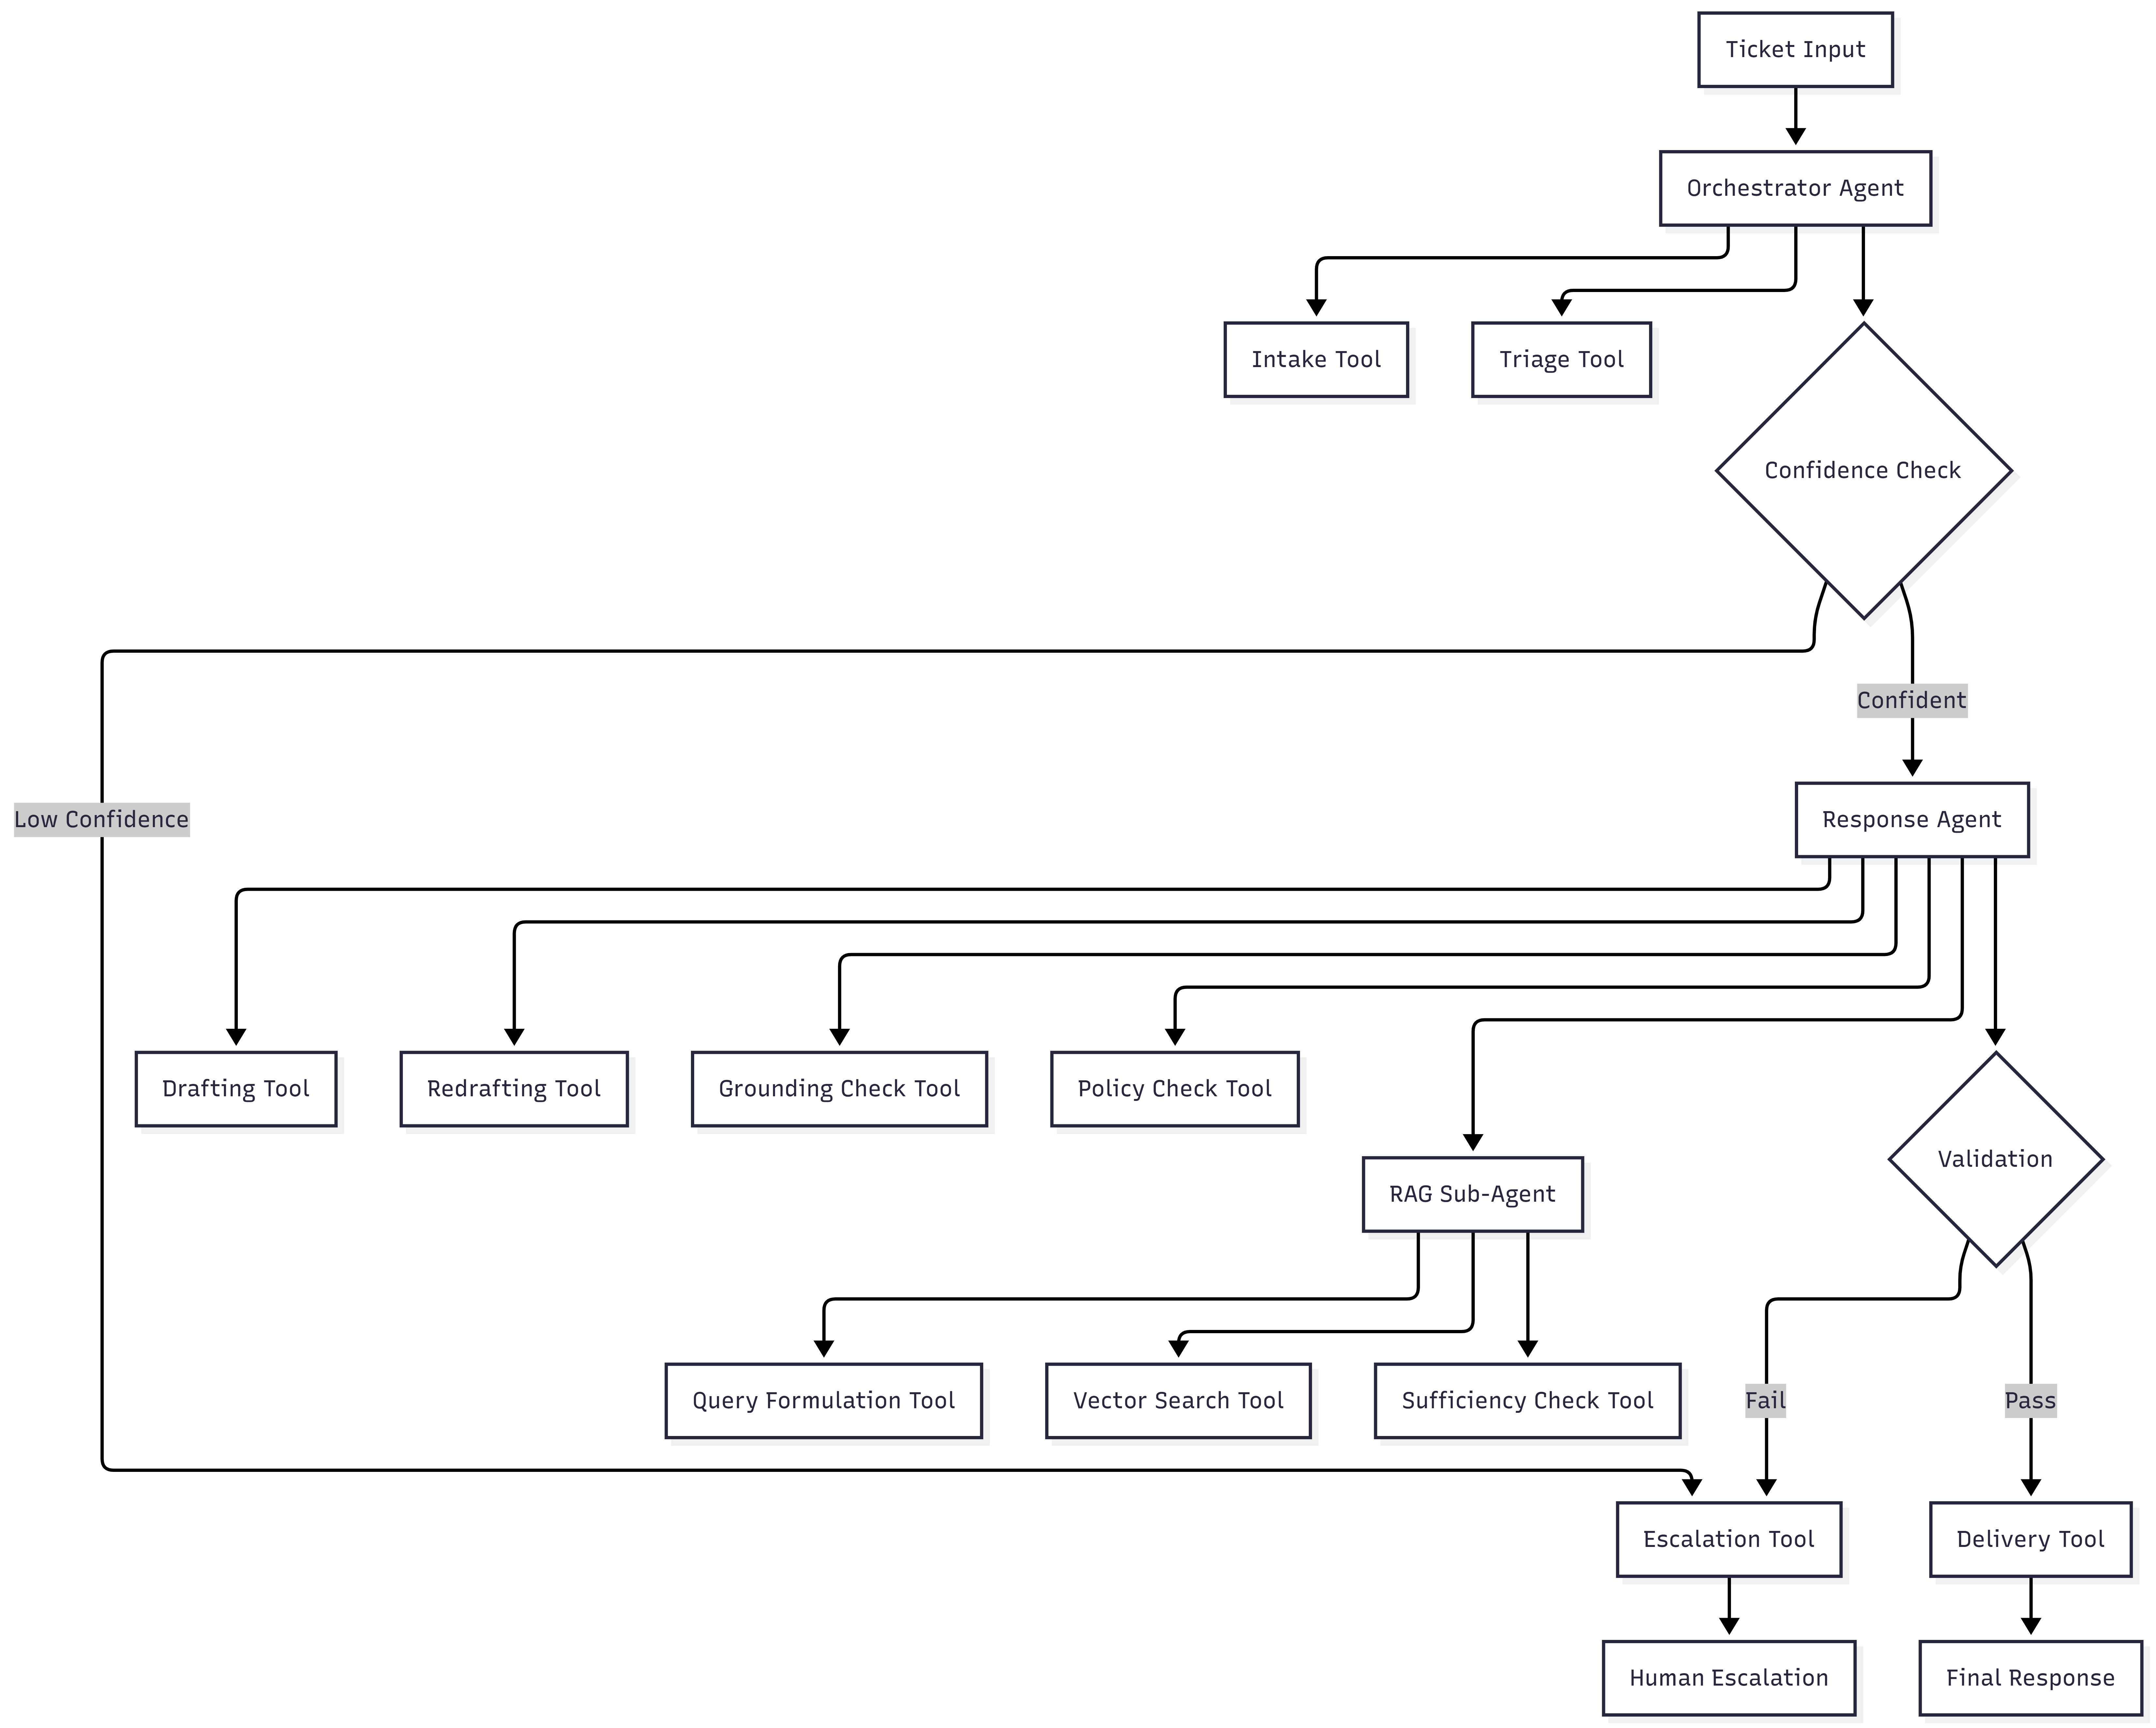

## **Installing and Importing Necessary Libraries and Dependencies**

In [ ]:
!pip install -q \
    langchain \
    langchain-openai \
    langgraph \
    langsmith \
    langchain-community \
    langchain-huggingface \
    openai \
    faiss-cpu \
    sentence-transformers \
    pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

**Note**: after running the install, restart the runtime (Colab) or kernel (Jupyter) and continue from the next cell.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import os
import re
import json
from typing import List, Optional, Literal, TypedDict, Annotated

import pandas as pd
from pydantic import BaseModel, Field

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langgraph.graph.message import add_messages

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

/tmp/ipykernel_4311/1932942588.py:18: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


## **LLM and Agent Observability Setup**

#### LangSmith Setup

In a multi-agent system, multiple agents and tools may run in sequence, passing state and intermediate results between them. As the workflow grows in complexity, it becomes challenging to understand:

- why a particular routing decision was made,
- which documents or chunks were retrieved,
- where an incorrect or unexpected output originated,

and more.

LangSmith provides observability for agentic AI workflows by logging:

- the end-to-end execution flow
- all tool and agent calls
- intermediate inputs and outputs
- key performance metrics

With LangSmith, one can debug errors, evaluate system behavior, and validate that a workflow is executing as intended. Without this level of tracing, diagnosing issues in complex agentic AI workflows becomes time-consuming and error-prone.

**How to obtain a LangSmith API Key?**

1. Visit: [https://smith.langchain.com](https://smith.langchain.com)  
2. Sign in and go to **Settings → API Keys**  
3. Generate a new API key  
4. Store this key securely (for example, in a `config.json` file or environment variables)

Example `config.json`:

```json
{
  "LANGCHAIN_TRACING_V2": "true",
  "LANGCHAIN_API_KEY": "your_langsmith_api_key",
  "LANGCHAIN_PROJECT": "your_langsmith_project_name"
}
```

The API key enables tracing for the specific project workspace.

**Note**: You can define a unique project name in LangSmith for each case study, and all traces and agent executions will be tracked and organized under that specific project for structured monitoring and comparison.


#### OpenAI API Setup

The credentials for OpenAI setup need to be stored in the same `config.json` file as the LangSmith credentials.

Example `config.json`:

```json
{
  "LANGCHAIN_TRACING_V2": "true",
  "LANGCHAIN_API_KEY": "your_langsmith_api_key",
  "LANGCHAIN_PROJECT": "your_langsmith_project_name",
  "OPENAI_API_KEY": "your_openai_key",
  "OPENAI_API_BASE": "your_openai_base_url"
}

We load all OpenAI and LangSmith credentials from a secure `config.json` file and store them as environment variables.

In [ ]:
# Load the JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary

    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                               # Extract OpenAI API key
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")                             # Extract OpenAI base URL

    LANGCHAIN_TRACING_V2 = config.get("LANGCHAIN_TRACING_V2")                   # Extract LangSmith tracing flag
    LANGCHAIN_API_KEY = config.get("LANGCHAIN_API_KEY")                         # Extract LangSmith API key
    LANGCHAIN_PROJECT = config.get("LANGCHAIN_PROJECT")                         # Extract LangSmith project name


# Store OpenAI credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                   # Set OpenAI API key
os.environ['OPENAI_BASE_URL'] = OPENAI_API_BASE                                 # Set OpenAI API base URL


# Store LangSmith credentials in environment variables
os.environ['LANGCHAIN_TRACING_V2'] = LANGCHAIN_TRACING_V2                       # Enable LangSmith tracing
os.environ['LANGCHAIN_API_KEY'] = LANGCHAIN_API_KEY                             # Set LangSmith API key
os.environ['LANGCHAIN_PROJECT'] = LANGCHAIN_PROJECT                             # Set LangSmith project

For the problem at hand, we will use two LLMs to separate responsibilities
- a lightweight model for primary reasoning and generation, and
- a more complex model for evaluation and validation, ensuring better accuracy, reliability, and cost efficiency.


In [ ]:
# Initialize LLM
llm_fast = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Initialize separate LLM for validation (more complex model)
llm_validator = ChatOpenAI(model="gpt-4o", temperature=0)

Initialize LangSmith client to enable tracing and evaluation of the agentic workflow, with automatic fallback if configuration is unavailable.

In [ ]:
from langsmith import traceable, Client
from langsmith.evaluation import evaluate

# Initialize LangSmith client
try:
    langsmith_client = Client()
    LANGSMITH_ENABLED = True
    print("LangSmith tracing enabled")
except:
    LANGSMITH_ENABLED = False
    print("LangSmith not configured - tracing disabled")

LangSmith tracing enabled


## **Data Loading**

Loads the previous customer support ticket dataset for storage in the database.


In [ ]:
file_path = "/content/ticket_data.csv"
df = pd.read_csv(file_path)

Combines the ticket subject and body into a single `text` column.


In [ ]:
df["text"] = df["subject"].fillna("") + "\n" + df["body"].fillna("")

Displays the dataset shape, number of unique queues, and the first 3 rows for a quick data overview.


In [ ]:
print(f"Shape: {df.shape}")
print(f"Unique queues: {df['queue'].nunique()}")
df.head(3)

Shape: (500, 8)
Unique queues: 10


,subject,body,answer,type,queue,priority,language,text
0,Reported Problem with Financial Data Integration,"Dear Customer Support, I am reporting an issue...","<name>, thank you for reporting the data integ...",Problem,General Inquiry,medium,en,Reported Problem with Financial Data Integrati...
1,NaN,Is it possible to receive comprehensive guidan...,I would be delighted to assist you in optimizi...,Request,Product Support,medium,en,\nIs it possible to receive comprehensive guid...
2,Request for Details on Adobe Sign HelloSign Su...,Can you please provide comprehensive details o...,<name> would be happy to provide information o...,Request,Billing and Payments,medium,en,Request for Details on Adobe Sign HelloSign Su...


### Valid Labels

Extracts the unique queues, ticket types, and priority values from the dataset.

In [ ]:
VALID_QUEUES = sorted(df["queue"].dropna().unique().tolist())
VALID_TYPES = sorted(df["type"].dropna().unique().tolist())
VALID_PRIORITIES = sorted(df["priority"].dropna().unique().tolist())

print("Queues:", VALID_QUEUES)
print("Types:", VALID_TYPES)
print("Priorities:", VALID_PRIORITIES)

Queues: ['Billing and Payments', 'Customer Service', 'General Inquiry', 'Human Resources', 'IT Support', 'Product Support', 'Returns and Exchanges', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Technical Support']
Types: ['Change', 'Incident', 'Problem', 'Request']
Priorities: ['high', 'low', 'medium']


## **Knowledge Base**



In this section, we build the knowledge base from previous ticket data and create storage to manage the evidence retrieved by the agent.

1. **Build Documents:** Create documents from the ticket context and resolution data.
2. **Create Vector Store:** Generate embeddings and store the documents in FAISS for semantic search.
3. **Store Evidence:** Create an evidence store to collect and manage retrieved documents.
4. **Format Evidence:** Format the retrieved evidence so it can be passed to the Response Agent.


Defines the embedding model and the path where the FAISS vector store will be saved.


In [ ]:
EMBED_MODEL = "BAAI/bge-large-en-v1.5"
VECTORSTORE_PATH = "helpdesk_vectorstore"

***Prompt:***

<font size=3 color="#4682B4"><b>Generate a Python function `build_kb_documents(df)` that converts each valid DataFrame row into a LangChain `Document`. Use `subject + body` as the ticket context, `answer` as the resolution, skip missing answers, and store `kb_id`, `queue`, `type`, `priority`, and `answer_only` as metadata.</b></font>

Creates knowledge-base documents by combining each ticket’s subject, body, and resolution, while storing ticket metadata for later retrieval.


In [ ]:
# Build LangChain Document objects from the knowledge base DataFrame
def build_kb_documents(df: pd.DataFrame) -> List[Document]:
    docs = []

    # Process each row in the DataFrame as one knowledge base entry
    for i, row in df.iterrows():

        # Get the resolution/answer and skip rows where it is missing
        answer = str(row.get("answer", "")).strip()
        if not answer or answer.lower() == "nan":
            continue

        # Extract the ticket subject and body
        subject = str(row.get("subject", "")).strip()
        body = str(row.get("body", "")).strip()

        # Combine subject and body to represent the original ticket context
        ticket_context = f"{subject}\n{body}".strip()

        # Combine the ticket context and its resolution
        # so both the problem and solution are available for semantic search
        page_content = f"Ticket: {ticket_context}\n\nResolution: {answer}"

        # Create a LangChain Document containing the content and metadata
        docs.append(Document(
            page_content=page_content,
            metadata={
                # Create a unique ID for each knowledge base entry
                "kb_id": f"KB_{i}",

                # Store additional ticket attributes as metadata
                "queue": row.get("queue", ""),
                "type": row.get("type", ""),
                "priority": row.get("priority", ""),

                # Keep the clean answer separately for citation/display
                "answer_only": answer,
            }
        ))

    # Return the complete list of knowledge base documents
    return docs

***Prompt:***

<font size=3 color="#4682B4"><b>Generate a Python function `get_vectorstore(docs, save_path)` that creates or loads a LangChain FAISS vectorstore. Use `HuggingFaceEmbeddings` with `EMBED_MODEL`. If `save_path` exists, load the existing FAISS index; otherwise, create one from `docs`, save it locally, and return it.</b></font>

Creates or loads the FAISS vector store by converting documents into embeddings and saving them for semantic search.


The `prompt` tells the embedding model to represent the query specifically for **semantic search**, helping FAISS find relevant knowledge-base documents.

In [ ]:
# Create or load a FAISS vectorstore for semantic search
def get_vectorstore(docs: List[Document], save_path: str) -> FAISS:

    # Initialize the embedding model used to convert text into vectors
    embeddings = HuggingFaceEmbeddings(
        model_name=EMBED_MODEL,
    )

    # If a previously saved vectorstore exists, load it instead of rebuilding it
    if os.path.exists(save_path):
        print(f"Loading existing vectorstore from {save_path}")

        # Load the saved FAISS index using the same embedding model
        return FAISS.load_local(
            save_path,
            embeddings,
            allow_dangerous_deserialization=True
        )

    # If no saved vectorstore exists, create a new one from the documents
    print(f"Building new vectorstore with {len(docs)} documents")

    # Convert documents into embeddings and store them in FAISS
    vs = FAISS.from_documents(docs, embeddings)

    # Save the vectorstore locally so it can be reused later
    vs.save_local(save_path)

    # Return the newly created vectorstore
    return vs

> **Note:** Building the vectorstore can take up to **20 minutes**, depending on the number of documents and compute resources.

In [ ]:
kb_docs = build_kb_documents(df)
vectorstore = get_vectorstore(kb_docs, VECTORSTORE_PATH)
print(f"Knowledge base ready: {len(kb_docs)} documents indexed")

***Prompt:***

<font size=3 color="#4682B4"><b>Generate this Python `EvidenceStore` class. It should store retrieved LangChain Documents, prevent duplicate documents using `kb_id`, provide methods to `add`, `all`, `clear`, and `summary`, and include simple comments explaining the logic. Also create `evidence_store = EvidenceStore()` for each workflow run.</b></font>

Creates a session-scoped evidence store to collect and deduplicate documents retrieved by the RAG Sub-Agent, which the Response Agent uses for grounded response generation.


In [ ]:
# Stores the evidence documents retrieved during a single workflow run
class EvidenceStore:
    """Session-scoped store for Document objects, since tools return strings to the LLM."""

    def __init__(self):
        # Store the retrieved Document objects
        self.docs: List[Document] = []

        # Track KB IDs that have already been added
        # This prevents duplicate documents from being stored
        self._seen_ids: set = set()

    def add(self, new_docs: List[Document]):
        # Add newly retrieved documents to the evidence store
        for d in new_docs:

            # Get the unique KB ID from the document metadata
            kb_id = d.metadata.get("kb_id")

            # Only add the document if it has not already been stored
            if kb_id not in self._seen_ids:
                self.docs.append(d)
                self._seen_ids.add(kb_id)

    def all(self) -> List[Document]:
        # Return all documents currently stored as evidence
        return list(self.docs)

    def clear(self):
        # Reset the evidence store
        self.docs = []
        self._seen_ids = set()

    def summary(self) -> str:
        # Return a message when no evidence has been collected
        if not self.docs:
            return "No evidence gathered yet."

        # Return the number of documents and their KB IDs
        return f"{len(self.docs)} documents in evidence store. IDs: {[d.metadata.get('kb_id') for d in self.docs]}"


# Create one shared evidence store for each workflow run
# This store should be reset at the beginning of every new ticket
evidence_store = EvidenceStore()

Formats the retrieved evidence into a clean, size-limited context for the Response Agent.


In [ ]:
def format_evidence(docs: List[Document], max_chars: int = 3500) -> str:
    parts, total = [], 0
    for d in docs:
        clean_answer = d.metadata.get("answer_only", d.page_content)
        chunk = f"[{d.metadata.get('kb_id')}] {clean_answer}"
        if total + len(chunk) > max_chars:
            break
        parts.append(chunk)
        total += len(chunk)
    return "\n\n".join(parts) if parts else "(no evidence retrieved)"

## **Tools: Orchestrator Agent**


In this section, we define the tools used by the Orchestrator Agent to manage the ticket workflow.

* **Intake Tool:** Parses the ticket and extracts clean ticket.
* **Triage Tool:** Classifies the queue, type, priority, and confidence.
* **Escalation Tool:** Routes low-confidence or failed cases to a human queue.
* **Delivery Tool:** Sends the validated response to the customer.


### Intake Tool



Normalizes the incoming ticket text and records that the ticket has been received.


In [ ]:
@traceable(name="intake_tool")
def intake_tool(ticket_text: str) -> str:
    ticket_text = (ticket_text or "").strip()
    return {
        "ticket_text": ticket_text,
        "reasoning_trail": ["✓ Intake: Ticket received and normalized"],
    }

### Triage Tool

Defines an LLM-based triage tool that classifies tickets into queue, type, priority, confidence, and reasoning using a structured output.


In [ ]:
class TriageResult(BaseModel):
    queue: str
    type: str
    priority: str
    confidence: float
    reasoning: str

In [ ]:
triage_prompt = ChatPromptTemplate.from_messages([
    ("system", f'''You are an expert support ticket classifier.

Your job is to read a customer support ticket and predict:
1. Which team (queue) should handle it
2. What type of ticket it is
3. The priority level

Valid queues to choose from:
{VALID_QUEUES}

Valid types: {VALID_TYPES}
Valid priorities: {VALID_PRIORITIES}

Rules:
- Pick the CLOSEST matching queue from the valid list
- Set confidence between 0.0 (very unsure) and 1.0 (very sure)
- If the ticket is vague or could match many queues, use lower confidence
- Always provide a brief reasoning for your classification

Return JSON matching the schema.'''),
    ("human", "Ticket:\n{ticket_text}"),
])

triage_chain = triage_prompt | llm_fast.with_structured_output(TriageResult)

Executes the LLM-based triage chain and returns the ticket classification as a structured dictionary.


In [ ]:
@traceable(name="triage_tool")
def triage_tool(ticket_text: str) -> dict:
    return triage_chain.invoke({"ticket_text": ticket_text}).model_dump()

### Escalation Tool

Escalates the ticket to a human agent with the specified reason and triage details.

In [ ]:
@traceable(name="escalation_tool")
def escalation_tool(reason: str, triage: dict) -> dict:
    print(f"[ESCALATE] queue={triage.get('queue')} reason={reason}")
    return {
        "final_response": f"[ESCALATED to human agent] Reason: {reason}",
        "escalated": True,
        "escalation_reason": reason,
    }


### Delivery Tool

Acts as the final node in the orchestration flow, passing through and returning the final response to the customer.


In [ ]:
@traceable(name="delivery_tool")
def delivery_tool(response: str) -> dict:
    print(f"[DELIVER] response length={len(response)} chars")
    return {
        "final_response": response,
        "escalated": False,
    }

## **Tools: RAG Sub-Agent**

The RAG Sub-Agent uses these tools to search the knowledge base and gather sufficient evidence for the support response.

* **Query Formulation Tool:** Generates 3 targeted search queries from the support ticket.
* **Vector Search Tool:** Searches the FAISS knowledge base and retrieves relevant evidence.
* **Sufficiency Check Tool:** Evaluates whether the retrieved evidence is sufficient to answer the ticket.


### Query Formulation Tool

An LLM-based tool that generates three targeted search queries from the support ticket to retrieve relevant knowledge base evidence.


In [ ]:
class QueryPlan(BaseModel):
    queries: List[str] = Field(..., min_length=3, max_length=3, description="Exactly 3 distinct search queries")

In [ ]:
query_prompt = ChatPromptTemplate.from_messages([
    ("system", '''You are planning knowledge base searches for a support ticket.

Rules:
- Generate EXACTLY 3 distinct, non-overlapping short queries (not full sentences)
- Focus on: product names, error codes, symptoms, processes
- Each query should cover a different angle (e.g. one for the symptom, one for the cause, one for the fix)
- If a rationale is provided from a prior failed retrieval, use it to target the missing information

Return JSON matching the schema.'''),
    ("human", "Ticket: {ticket_text}\n\nContext / prior gap rationale: {rationale}"),
])

query_chain = query_prompt | llm_fast.with_structured_output(QueryPlan)

In [ ]:
@tool
@traceable(name="query_formulation_tool")
def query_formulation_tool(ticket_text: str, rationale: str = "") -> str:

    """Generate exactly 3 distinct search queries for the knowledge base.
    Optionally accepts a rationale from a prior failed retrieval to target missing info.
    Returns the queries as a numbered list."""

    plan = query_chain.invoke({"ticket_text": ticket_text, "rationale": rationale or "None"})

    return "\n".join(f"{i+1}. {q}" for i, q in enumerate(plan.queries))

### Vector Search Tool

The Vector Search Tool retrieves relevant evidence from the FAISS knowledge base for the queries generated by the RAG Sub-Agent.

1. **Parse Queries:** Extracts individual queries from the input and removes numbering.
2. **Search FAISS:** Runs each query once against the vector store to find similar documents.
3. **Deduplicate Results:** Removes duplicate documents using their `kb_id`.
4. **Store Evidence:** Adds the unique retrieved documents to the shared evidence store.
5. **Return Metadata:** Returns the retrieved document IDs, queues, similarity scores, and evidence-store summary for the agent.


***Prompt:***

<font size=3 color="#4682B4"><b>Generate this `vector_search_tool` using LangChain + FAISS. It should parse newline-separated queries, remove numbering, run similarity search, deduplicate results by `kb_id`, add unique documents to `evidence_store`, and return retrieved IDs, queues, scores, and an evidence-store summary.</b></font>

In [ ]:
@tool
@traceable(name="vector_search_tool")
def vector_search_tool(queries: str, k: int = 4) -> str:
    """Run vector search against the KB using newline-separated queries."""

    # 1. Parse Queries:
    # Extract individual queries and remove numbering such as "1. " or "2) "
    query_list = []
    for line in queries.strip().split("\n"):
        line = line.strip()
        if not line:
            continue

        line = re.sub(r"^\d+[\.\)]\s*", "", line)
        query_list.append(line)

    if not query_list:
        return "No queries provided."

    new_docs = []
    metadata_log = []
    seen_this_call = set()

    # 2. Search FAISS:
    # Run each query once against the FAISS vector store
    for q in query_list:
        results = vectorstore.similarity_search_with_score(q, k=k)

        for doc, score in results:
            kb_id = doc.metadata.get("kb_id")

            # 3. Deduplicate Results:
            # Skip documents that were already retrieved during this call
            if kb_id in seen_this_call:
                continue

            seen_this_call.add(kb_id)
            new_docs.append(doc)

            # Capture metadata for the agent to reason about the results
            metadata_log.append({
                "query": q[:40],
                "kb_id": kb_id,
                "queue": doc.metadata.get("queue"),
                "score": round(float(score), 3),
            })

    # 4. Store Evidence:
    # Add the unique retrieved documents to the shared evidence store
    evidence_store.add(new_docs)

    # 5. Return Metadata:
    # Return retrieved IDs, queues, similarity scores,
    # and the current evidence-store summary
    lines = [
        f"Retrieved {len(new_docs)} new unique docs "
        f"across {len(query_list)} queries."
    ]

    for m in metadata_log[:10]:
        lines.append(f"  {m}")

    lines.append(f"\nEvidence store now: {evidence_store.summary()}")

    return "\n".join(lines)

### Sufficiency Check Tool

An LLM-based tool that evaluates whether the retrieved evidence is sufficient to answer the support ticket and identifies any missing information.


In [ ]:
class Sufficiency(BaseModel):
    sufficient: bool
    missing_info: List[str] = Field(default_factory=list)
    rationale: str


In [ ]:
sufficiency_prompt = ChatPromptTemplate.from_messages([
    ("system", '''You are evaluating whether retrieved knowledge base articles are sufficient to answer a support ticket.

Check if the evidence covers:
- The root cause or explanation of the issue
- Specific troubleshooting steps
- Any relevant policies or SLA information

If insufficient, list what is missing and explain in the rationale.'''),
    ("human", "Ticket: {ticket}\n\nEvidence in store:\n{evidence}"),
])

sufficiency_chain = sufficiency_prompt | llm_fast.with_structured_output(Sufficiency)

In [ ]:
@tool
@traceable(name="sufficiency_check_tool")
def sufficiency_check_tool(ticket_text: str) -> str:
    """Judge if the evidence currently in the store is sufficient to answer the ticket.
    Returns a verdict (sufficient yes/no), what is missing, and a rationale."""
    result = sufficiency_chain.invoke({
        "ticket": ticket_text,
        "evidence": format_evidence(evidence_store.all()),
    })
    return json.dumps(result.model_dump(), indent=2)

## **RAG Sub-Agent**



The RAG Sub-Agent autonomously manages the evidence-gathering process using a ReAct loop with built-in verification.

* **Agent Loop:** Decides which tool to call and when to continue or stop.
* **Evidence Retrieval:** Formulates queries and searches the FAISS knowledge base.
* **Evidence Verification:** Checks whether the retrieved evidence is sufficient.
* **Safety Check:** Ensures `sufficiency_check_tool` is called before the agent finishes.


In [ ]:
class RagAgentState(TypedDict):
  messages: Annotated[List, add_messages]

In [ ]:
RAG_AGENT_SYSTEM = '''You are the RAG Sub-Agent. Your job is to gather evidence from the knowledge base to answer a support ticket.

You have three tools:
- query_formulation_tool: generates exactly 3 distinct search queries. Accepts an optional rationale.
- vector_search_tool: runs a list of queries against the KB, adds results to the shared evidence store.
- sufficiency_check_tool: independent judgment on whether the evidence covers the ticket.

Standard flow:
1. Call query_formulation_tool to get 3 queries.
2. Call vector_search_tool with those queries.
3. Call sufficiency_check_tool to verify.
4. If insufficient, call query_formulation_tool AGAIN with the rationale from sufficiency_check to target missing info, then vector_search_tool again, then sufficiency_check again.
5. Once sufficient (or after ~2 reformulation attempts), stop and respond with a short summary.

You MUST call sufficiency_check_tool at least once before finishing. Do not stop after just searching. Verify.
Keep the loop short. If evidence is still thin after 2 reformulations, stop and let the downstream drafter acknowledge gaps.'''


In [ ]:
RAG_TOOLS = [query_formulation_tool, vector_search_tool, sufficiency_check_tool]

rag_llm = llm_fast.bind_tools(RAG_TOOLS)

Invokes the RAG LLM to decide the next tool or action.

In [ ]:
def rag_agent_node(state):
    response = rag_llm.invoke(state["messages"])
    return {"messages": [response]}  # add_messages will append

Checks whether the LLM requested a tool call or has finished.

In [ ]:
def rag_should_continue(state: RagAgentState) -> Literal["tools", "check", "end"]:
    """Standard should_continue: if the LLM emitted tool_calls, execute them; else finish."""
    last = state["messages"][-1]
    if getattr(last, "tool_calls", None):
        return "tools"
    # LLM is done; go to safety check
    return "check"

Verifies that the sufficiency check was performed before completion.

In [ ]:
# Safety-check node that ensures the agent verifies evidence before finishing
def rag_safety_check_node(state: RagAgentState) -> dict:
    """Check whether sufficiency_check_tool was actually called."""

    # Track all tools that have been called during the workflow
    called_tools = set()

    for msg in state["messages"]:
        # Check AI messages for tool calls
        if isinstance(msg, AIMessage) and getattr(msg, "tool_calls", None):
            for tc in msg.tool_calls:
                called_tools.add(tc["name"])

    # If the sufficiency check was not called, force the agent to call it
    if "sufficiency_check_tool" not in called_tools:

        # Add a message instructing the LLM to verify the evidence
        nudge = HumanMessage(content=(
            "You did not call sufficiency_check_tool. You must verify the evidence before finishing. "
            "Call sufficiency_check_tool now, then finish."
        ))

        # Return the updated message history and mark that a safety nudge occurred
        return {
            "messages": state["messages"] + [nudge],
            "_safety_nudged": True
        }

    # If the required tool was already called, no state change is needed
    return {}

Routes the workflow back to the agent if the safety check was skipped.

In [ ]:
def rag_after_check_route(state: RagAgentState) -> Literal["agent", "end"]:
  """If we nudged the LLM, loop back to agent. Otherwise end."""
  # Detect nudge by checking last message
  last = state["messages"][-1]
  if isinstance(last, HumanMessage) and "sufficiency_check_tool" in last.content:
    return "agent"
  return "end"

In [ ]:
# Build the RAG sub-agent graph: agent <-> tools loop, then safety check
rag_tool_node = ToolNode(RAG_TOOLS)

rag_graph = StateGraph(RagAgentState)
rag_graph.add_node("agent", rag_agent_node)
rag_graph.add_node("tools", rag_tool_node)
rag_graph.add_node("check", rag_safety_check_node)

rag_graph.add_edge(START, "agent")
rag_graph.add_conditional_edges("agent", rag_should_continue, {
    "tools": "tools",
    "check": "check",
})
rag_graph.add_edge("tools", "agent")
rag_graph.add_conditional_edges("check", rag_after_check_route, {
    "agent": "agent",
    "end": END,
})

rag_sub_agent_graph = rag_graph.compile()
print("RAG Sub-Agent compiled (ReAct loop with should_continue + safety check).")

RAG Sub-Agent compiled (ReAct loop with should_continue + safety check).


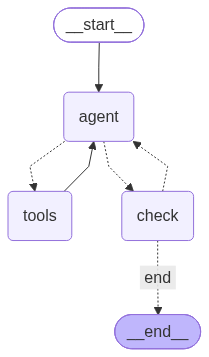

In [ ]:
from IPython.display import Image
Image(rag_sub_agent_graph.get_graph().draw_mermaid_png())

Runs the complete RAG sub-agent workflow for a support ticket.

In [ ]:
@traceable(name="run_rag_sub_agent")
def run_rag_sub_agent(ticket_text: str, rationale: str = "") -> str:
    """Entry point: invoke the RAG sub-agent. Returns a short status summary.
    The gathered evidence is available in the shared evidence_store."""
    task = f"Gather evidence for this ticket:\n{ticket_text}"
    if rationale:
        task += f"\n\nPrior attempt was insufficient. Rationale for what is missing: {rationale}"

    initial = {
        "messages": [
            SystemMessage(content=RAG_AGENT_SYSTEM),
            HumanMessage(content=task),
        ]
    }
    final = rag_sub_agent_graph.invoke(initial, {"recursion_limit": 25})
    return f"Evidence gathering complete. {evidence_store.summary()}"

## **Tools: Response Agent**

The Response Agent uses these tools to draft, validate, revise, and ground the final customer response.

* **Drafting Tool:** Generates the initial response using only the retrieved evidence.
* **Redrafting Tool:** Revises the response based on validator feedback without fetching new information.
* **Grounding Check Tool:** Verifies that factual claims in the response are supported by cited evidence.
* **Policy Check Tool:** Applies deterministic rules to detect prohibited claims or content.
* **RAG Sub-Agent Tool:** Requests additional evidence when the current evidence is insufficient.

### Drafting Tool

An LLM-based tool that generates the first customer response using only the available evidence and cites the supporting knowledge-base sources.

In [ ]:
draft_prompt = ChatPromptTemplate.from_messages([
    ("system", '''You are assembling a first-response email using ONLY the evidence provided. This is not a creative writing task, it is an assembly task.

STRICT RULES:
- Every sentence in your response must directly restate something explicitly present in the evidence. Do not add transitions, promises, warmth, or detail that is not in the evidence.
- Cite every factual sentence with (source: KB_X) immediately after it.
- If the evidence is a deferral (asks for more details, offers a call, points to a website), your response should be that same deferral, restated plainly. Do not upgrade it into a more specific or more helpful-sounding answer.
- Do not merge or reinterpret multiple evidence items into a new combined claim. If two sources say slightly different things, cite them separately.
- Keep a brief greeting and closing, but do not add any claim, promise, or detail inside them.
- When in doubt, choose the shorter response. A shorter response that mirrors the evidence exactly will always pass; a longer, embellished one will not.

Format: Greeting, then the cited evidence sentence(s) as-is, then a plain closing offering further help.'''),
    ("human", "Ticket: {ticket_text}\n\nEvidence from Knowledge Base:\n{evidence}\n\nWrite the response now."),
])


drafter_chain = draft_prompt | llm_fast | StrOutputParser()

In [ ]:
@tool
@traceable(name="drafting_tool")
def drafting_tool(ticket_text: str) -> str:
    """Write the first-response email using the evidence currently in the store."""
    return drafter_chain.invoke({
        "ticket_text": ticket_text,
        "evidence": format_evidence(evidence_store.all()),
    })

### Redrafting Tool

An LLM-based tool that revises a failed response based on validation feedback while using the same evidence.


In [ ]:
redraft_prompt = ChatPromptTemplate.from_messages([
    ("system", '''You are revising a support response that failed validation. The evidence in the KB is FIXED; your job is to fix the WORDING, not to fetch more information.

STRICT RULES:
- Only use information EXPLICITLY present in the evidence below.
- Cite every factual claim with (source: KB_X).
- If a claim was flagged as ungrounded: either REMOVE it entirely, or REPLACE it with a properly cited fact from the evidence. Do not try to save an ungrounded claim by rephrasing.
- If a policy violation was flagged: rewrite that section to comply. Common fixes: remove refund promises, remove specific time commitments, remove credential requests.
- Prefer a SHORTER, cleaner revision over one that tries to preserve every part of the original draft.
- Do not add new facts that were not in the original draft unless they come directly from the evidence.'''),
    ("human", '''Original ticket: {ticket_text}

Evidence (unchanged, do not expect more):
{evidence}

Previous draft (failed validation):
{previous_draft}

Validator feedback to address:
{feedback}

Write the revised response now.'''),
])

redrafter_chain = redraft_prompt | llm_fast | StrOutputParser()


In [ ]:
@tool
@traceable(name="redrafting_tool")
def redrafting_tool(ticket_text: str, previous_draft: str, feedback: str) -> str:
    """Revise a failed draft using the validator's feedback. Same evidence store is used."""
    return redrafter_chain.invoke({
        "ticket_text": ticket_text,
        "evidence": format_evidence(evidence_store.all()),
        "previous_draft": previous_draft,
        "feedback": feedback,
    })

### Grounding Check Tool

An LLM-based tool that checks whether factual claims in the response are supported by the retrieved evidence and valid citations.

In [ ]:
# `Claim` is a nested Pydantic model used within `ClaimAnalysis` to represent and evaluate individual claims in the response.

class Claim(BaseModel):
    claim_text: str
    needs_evidence: bool
    cited_sources: List[str] = Field(default_factory=list)
    is_grounded: bool


class ClaimAnalysis(BaseModel):
    claims: List[Claim]
    overall_grounded: bool
    ungrounded_claims: List[str] = Field(default_factory=list)
    rationale: str = ""

In [ ]:
claim_extractor_prompt = ChatPromptTemplate.from_messages([
    ("system", '''You are fact-checking a customer support response against its evidence.

Check each factual claim: is it actually stated in the evidence, not just similar to it? Courtesy lines, questions, and offers to help don't need evidence.

Rubric for each claim:
- Grounded: the evidence states this exact information
- Not grounded: the evidence is silent on this, describes a different situation, or the claim blends details from multiple sources into something none of them state alone

Valid source IDs: {valid_sources}

If a claim isn't supported, briefly say what's missing or mismatched.

Return JSON matching the schema.'''),
    ("human", "Response to analyze:\n{response}"),
])
claim_extractor = claim_extractor_prompt | llm_validator.with_structured_output(ClaimAnalysis)

In [ ]:
@tool
@traceable(name="grounding_check_tool")
def grounding_check_tool(response: str) -> str:
    """Check if every factual claim in the response is grounded in the evidence store.
    Returns a JSON verdict with overall_grounded, ungrounded_claims, and a rationale."""
    valid_sources = [d.metadata.get("kb_id") for d in evidence_store.all()]
    result = claim_extractor.invoke({
        "response": response,
        "valid_sources": valid_sources,
    })
    return json.dumps(result.model_dump(), indent=2)


###Policy Check Tool

A deterministic tool that checks the response against predefined policy rules using regex patterns.

In [ ]:
POLICY_RULES = [
    {
        "name": "no_refund_promises",
        "pattern": re.compile(r"\b(will\s+(be\s+)?refund(ed)?|will\s+issue\s+.*refund|we\s+refund|refunding\s+you)\b", re.IGNORECASE),
        "message": "Response promises a refund without manager approval.",
    },
    {
        "name": "no_credential_requests",
        "pattern": re.compile(r"(send\s+.*password|share\s+.*password|provide\s+.*password|what\s+is\s+your\s+password|your\s+login\s+credentials)", re.IGNORECASE),
        "message": "Response requests or discusses user credentials.",
    },
    {
        "name": "no_specific_timelines",
        "pattern": re.compile(r"\bwithin\s+\d+\s+(hour|minute|day|business\s+day)s?\b", re.IGNORECASE),
        "message": "Response promises a specific resolution timeline.",
    },
    {
        "name": "escalate_legal_issues",
        "pattern": re.compile(r"\b(lawsuit|litigation|attorney|legal\s+action|court)\b", re.IGNORECASE),
        "message": "Legal matters must be escalated to the legal team.",
    },
]


In [ ]:
@tool
@traceable(name="policy_check_tool")
def policy_check_tool(response: str) -> str:
    """Check the response against deterministic policy rules (regex).
    Returns a JSON verdict with compliant flag and violations."""
    violations = []
    for rule in POLICY_RULES:
        if rule["pattern"].search(response):
            violations.append({"rule": rule["name"], "message": rule["message"]})
    return json.dumps({
        "compliant": len(violations) == 0,
        "violations": violations,
    }, indent=2)

### Rag Sub-Agent Tool (nested agent as a tool)

A nested agent tool that requests additional evidence from the RAG Sub-Agent when the current evidence is insufficient.

**Note:** Here, the RAG Sub-Agent is wrapped as a **tool** for the Response Agent to invoke. This is one integration approach; other agent-to-agent communication patterns are also possible.


In [ ]:
@tool
@traceable(name="rag_sub_agent_tool")
def rag_sub_agent_tool(ticket_text: str, rationale: str) -> str:
    """Invoke the RAG Sub-Agent to gather more evidence. Pass a rationale explaining
    what is missing from the current evidence so it can target its search. Returns a
    summary of the updated evidence store."""
    return run_rag_sub_agent(ticket_text, rationale=rationale)

## **Response Agent**

The Response Agent autonomously manages response generation and validation using a ReAct loop with built-in safety checks.

* **Agent Loop:** Decides whether to draft, validate, revise, or request more evidence.
* **Response Generation:** Creates and revises the customer response using retrieved evidence.
* **Response Validation:** Checks the response for grounding and policy compliance.
* **Safety Check:** Ensures both `grounding_check_tool` and `policy_check_tool` are called before the agent finishes.


In [ ]:
class ResponseAgentState(TypedDict):
    messages: Annotated[List, add_messages]

In [ ]:
RESPONSE_TOOLS = [
    drafting_tool,
    redrafting_tool,
    grounding_check_tool,
    policy_check_tool,
    rag_sub_agent_tool,
]

response_tool_node = ToolNode(RESPONSE_TOOLS)

In [ ]:
RESPONSE_AGENT_SYSTEM = '''You are the Response Agent. Your job is to produce a grounded, policy-compliant response to a customer support ticket.

You have five tools:
- drafting_tool: writes a first draft using evidence currently in the store
- redrafting_tool: revises a draft using validator feedback (same evidence store)
- grounding_check_tool: checks if every factual claim in a draft is grounded in the evidence
- policy_check_tool: checks a draft against deterministic policy rules
- rag_sub_agent_tool: invokes the RAG Sub-Agent to gather more evidence; pass a rationale describing what is missing

Standard flow:
1. Call rag_sub_agent_tool with a rationale based on the ticket itself (what information is needed).
2. Call drafting_tool to produce a first draft from the gathered evidence.
3. Call grounding_check_tool AND policy_check_tool on that draft. Both are required.
4. Read the verdicts:
   - If both pass: stop and respond with the final draft as your final answer (no more tool calls).
   - If grounding failed: check whether the evidence store is still empty or clearly missing the topic. If so, this is an evidence gap: call rag_sub_agent_tool again (budget: 1 additional bounce) with a rationale.
   - If grounding failed and the evidence store DOES contain relevant material but the draft simply drifted or overclaimed: call redrafting_tool instead (budget: 1 redraft).
   - If policy failed: call redrafting_tool. Policy issues are always wording issues.
5. Hard budget: at most 1 additional rag_sub_agent_tool call (2 total including the mandatory first call) and at most 1 redrafting_tool call. If problems remain after these are exhausted, stop and state that escalation is required.

You MUST call both grounding_check_tool AND policy_check_tool on the final draft before finishing.
When you are done, your final message should contain the final response text (or an escalation note), with no more tool calls.'''

response_llm = llm_validator.bind_tools(RESPONSE_TOOLS)

Invokes the LLM to decide the next action or tool.

In [ ]:
def response_agent_node(state) -> dict:
    response = response_llm.invoke(state["messages"])
    return {"messages": [response]}

Checks whether the LLM requested a tool call or has finished.

In [ ]:
def response_should_continue(state: ResponseAgentState) -> Literal["tools", "check"]:
    last = state["messages"][-1]
    if getattr(last, "tool_calls", None):
        return "tools"
    return "check"


Ensures both grounding and policy validation were performed on the final draft.

In [ ]:
# Safety-check node that ensures the final draft passes both grounding and policy checks
def response_safety_check_node(state: ResponseAgentState) -> dict:
    """Check whether grounding_check_tool and policy_check_tool were both called on the final draft."""

    # Find the position of the most recent drafting or redrafting tool call
    last_draft_idx = -1

    for i, msg in enumerate(state["messages"]):
        if isinstance(msg, AIMessage) and getattr(msg, "tool_calls", None):
            for tc in msg.tool_calls:
                if tc["name"] in ("drafting_tool", "redrafting_tool"):
                    last_draft_idx = i

    # If no draft was created, instruct the agent to create one
    if last_draft_idx == -1:
        nudge = HumanMessage(
            content="You did not produce any draft. Call drafting_tool now."
        )
        return {
            "messages": state["messages"] + [nudge],
            "_nudged": True
        }

    # Check which tools were called after the most recent draft
    called_after_draft = set()

    for msg in state["messages"][last_draft_idx + 1:]:
        if isinstance(msg, AIMessage) and getattr(msg, "tool_calls", None):
            for tc in msg.tool_calls:
                called_after_draft.add(tc["name"])

    # Identify any required safety checks that are missing
    missing = []

    if "grounding_check_tool" not in called_after_draft:
        missing.append("grounding_check_tool")

    if "policy_check_tool" not in called_after_draft:
        missing.append("policy_check_tool")

    # If either check is missing, instruct the agent to run it
    if missing:
        nudge = HumanMessage(content=(
            f"You did not call {', '.join(missing)} on the final draft. "
            "Both grounding_check_tool and policy_check_tool must be run on the final draft before finishing. "
            "Call the missing tool(s) now, then finish."
        ))

        return {
            "messages": state["messages"] + [nudge],
            "_nudged": True
        }

    # If both checks were completed, allow the workflow to continue
    return {}

Sends the workflow back to the agent if required validation was skipped.

In [ ]:
def response_after_check_route(state: ResponseAgentState) -> Literal["agent", "end"]:
    last = state["messages"][-1]
    if isinstance(last, HumanMessage) and (
        "did not call" in last.content or "did not produce" in last.content
    ):
        return "agent"
    return "end"


In [ ]:
response_graph = StateGraph(ResponseAgentState)
response_graph.add_node("agent", response_agent_node)
response_graph.add_node("tools", response_tool_node)
response_graph.add_node("check", response_safety_check_node)

response_graph.add_edge(START, "agent")
response_graph.add_conditional_edges("agent", response_should_continue, {
    "tools": "tools",
    "check": "check",
})
response_graph.add_edge("tools", "agent")
response_graph.add_conditional_edges("check", response_after_check_route, {
    "agent": "agent",
    "end": END,
})

response_agent_graph = response_graph.compile()
print("Response Agent compiled (ReAct loop with should_continue + safety check).")

Response Agent compiled (ReAct loop with should_continue + safety check).


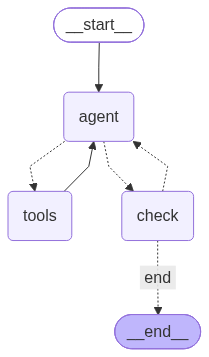

In [ ]:
from IPython.display import Image
Image(response_agent_graph.get_graph().draw_mermaid_png())

Executes the complete response workflow and returns the final response with validation results.

In [ ]:
@traceable(name="run_response_agent")
def run_response_agent(ticket_text: str, triage: dict) -> dict:
    """Entry point: invoke the Response Agent. Returns the final draft and validation outcome."""
    task = (
        f"Ticket:\n{ticket_text}\n\n"
        f"Triage: {triage}\n\n"
        "Produce a grounded, policy-compliant response. Follow your standard flow."
    )

    initial = {
        "messages": [
            SystemMessage(content=RESPONSE_AGENT_SYSTEM),
            HumanMessage(content=task),
        ]
    }
    final = response_agent_graph.invoke(initial, {"recursion_limit": 40})

    # The final assistant message contains the response text
    final_text = ""
    for msg in reversed(final["messages"]):
        if isinstance(msg, AIMessage) and not getattr(msg, "tool_calls", None):
            final_text = msg.content
            break

    # Extract the last grounding and policy verdicts from ToolMessages
    grounding = {}
    policy = {}
    for msg in final["messages"]:
        if isinstance(msg, ToolMessage):
            if msg.name == "grounding_check_tool":
                try:
                    grounding = json.loads(msg.content)
                except Exception:
                    grounding = {}
            elif msg.name == "policy_check_tool":
                try:
                    policy = json.loads(msg.content)
                except Exception:
                    policy = {}

    return {
        "final_text": final_text,
        "grounding": grounding,
        "policy": policy,
        "messages": final["messages"],
    }

## **Orchestrator Agent**

The Orchestrator manages the end-to-end ticket workflow using a deterministic StateGraph with clear routing and pass/fail decisions.

* **Ticket Intake:** Receives and normalizes the ticket before processing.
* **Triage:** Classifies the ticket and determines the confidence level.
* **Agent Routing:** Sends high-confidence tickets to the Response Agent and low-confidence tickets to escalation.
* **Final Routing:** Delivers validated responses or escalates failed responses to a human agent.


In [ ]:
class OrchestratorState(TypedDict, total=False):
    ticket_text: str
    intake: dict
    triage: dict
    response_output: dict
    final_response: str
    escalated: bool
    escalation_reason: str
    reasoning_trail: List[str]

Resets the evidence store and processes the incoming ticket through the intake tool.

In [ ]:
def intake_node(state: OrchestratorState) -> dict:
    # Reset the evidence store for each new ticket
    evidence_store.clear()

    result = intake_tool(state["ticket_text"])
    trail = state.get("reasoning_trail", [])

    return {
        "intake": result,
        "ticket_text": result.get("ticket_text"),
        "reasoning_trail": trail,
    }

Classifies the ticket and records its queue, priority, confidence, and reasoning.

In [ ]:
def triage_node(state: OrchestratorState) -> dict:
    result = triage_tool(state["ticket_text"])
    trail = state.get("reasoning_trail", []) + [
        f"Triage: queue={result['queue']} priority={result['priority']} confidence={result['confidence']:.2f}"
    ]
    return {"triage": result, "reasoning_trail": trail}
TRIAGE_CONF_THRESHOLD = 0.6


Routes the ticket to the Response Agent or escalation based on the confidence threshold.

In [ ]:
def triage_route(state: OrchestratorState) -> Literal["response", "escalate"]:
    if state["triage"].get("confidence", 0.0) < TRIAGE_CONF_THRESHOLD:
        return "escalate"
    return "response"

Invokes the Response Agent to generate and validate the customer response.

In [ ]:
def response_agent_node_orch(state: OrchestratorState) -> dict:
    """Orchestrator node that invokes the Response Agent (ReAct loop)."""
    output = run_response_agent(state["ticket_text"], state["triage"])
    trail = state.get("reasoning_trail", []) + [
        f"Response Agent finished. Grounded={output['grounding'].get('overall_grounded')} "
        f"Compliant={output['policy'].get('compliant')}"
    ]
    return {"response_output": output, "reasoning_trail": trail}

Routes the workflow to delivery if the response passes validation, otherwise to escalation.

In [ ]:
def after_response_route(state: OrchestratorState) -> Literal["deliver", "escalate"]:
    output = state.get("response_output", {})
    grounded = output.get("grounding", {}).get("overall_grounded", False)
    compliant = output.get("policy", {}).get("compliant", False)
    if grounded and compliant and output.get("final_text"):
        return "deliver"
    return "escalate"

Escalates the ticket to a human agent with the appropriate reason.

In [ ]:
def escalate_node(state: OrchestratorState) -> dict:
    if state.get("triage", {}).get("confidence", 1.0) < TRIAGE_CONF_THRESHOLD:
        reason = f"low triage confidence ({state['triage']['confidence']:.2f})"
    else:
        output = state.get("response_output", {})
        grounded = output.get("grounding", {}).get("overall_grounded", True)
        compliant = output.get("policy", {}).get("compliant", True)
        if not grounded:
            reason = "grounding failure after agent retries"
        elif not compliant:
            reason = "policy violation after agent retries"
        else:
            reason = "response agent did not produce a valid final answer"

    out = escalation_tool(reason, state.get("triage", {}))
    trail = state.get("reasoning_trail", []) + [f"Orchestrator: escalated ({reason})"]
    out["reasoning_trail"] = trail
    return out

Passes the validated response to the delivery tool and returns it as the final answer.

In [ ]:
def deliver_node(state: OrchestratorState) -> dict:
    text = state["response_output"]["final_text"]
    out = delivery_tool(text)
    trail = state.get("reasoning_trail", []) + ["Orchestrator: delivered response"]
    out["reasoning_trail"] = trail
    return out


In [ ]:
# Build the Orchestrator
orch = StateGraph(OrchestratorState)
orch.add_node("intake", intake_node)
orch.add_node("triage", triage_node)
orch.add_node("response", response_agent_node_orch)
orch.add_node("escalate", escalate_node)
orch.add_node("deliver", deliver_node)

orch.add_edge(START, "intake")
orch.add_edge("intake", "triage")
orch.add_conditional_edges("triage", triage_route, {
    "response": "response",
    "escalate": "escalate",
})
orch.add_conditional_edges("response", after_response_route, {
    "deliver": "deliver",
    "escalate": "escalate",
})
orch.add_edge("escalate", END)
orch.add_edge("deliver", END)

app = orch.compile()
print("Orchestrator compiled.")

Orchestrator compiled.


**Workflow Visualization**

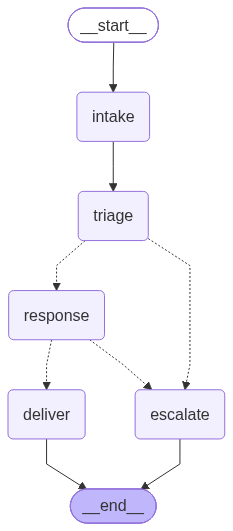

In [ ]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

## **Test Cases**

Defines representative scenarios to systematically evaluate routing, grounding, escalation, and retrieval behavior across different ticket types.

In [ ]:
TEST_CASES = [
    {
        "id": 1,
        "scenario": "QuickBooks Integration Inquiry (Common Product Support)",
        "ticket": (
            "Subject: Integration options for QuickBooks Online\n"
            "Hello, we are evaluating your platform for our finance team and want to "
            "understand what integration options are available for QuickBooks Online. "
            "Could you share details on available API connections, third-party connectors, "
            "and any setup instructions? Any information on limitations would also help."
        ),
        "expected": "Full pipeline. KB has direct QuickBooks integration articles, should draft grounded response.",
    },
    {
        "id": 2,
        "scenario": "Billing Settlement Dispute (Billing and Payments)",
        "ticket": (
            "Subject: Payment made but invoice still shows unpaid\n"
            "I have tried to settle my latest invoice multiple times. Each transaction "
            "appears successful on my end but my account still shows an unpaid balance. "
            "I have verified my payment details are correct. Please investigate and "
            "confirm the correct status of my account."
        ),
        "expected": "Full pipeline. Policy check should catch any refund/credit promises; expect grounded response asking for invoice number and payment details.",
    },
    {
        "id": 3,
        "scenario": "USB Storage Not Detected (IT Support)",
        "ticket": (
            "Subject: Computer no longer recognizes USB drives\n"
            "My computer has stopped recognizing any USB storage device when connected. "
            "The issue happens regardless of which port or drive I use. I have tested "
            "multiple drives, tried different ports, restarted the PC, and updated my "
            "USB drivers. Nothing has worked so far. Please advise on next steps."
        ),
        "expected": "Full pipeline. KB contains direct USB detection articles; drafter should cite troubleshooting steps.",
    },
    {
        "id": 4,
        "scenario": "Mailchimp Integration Technical Request; (Grounding Failure, Escalation Test)",
        "ticket": (
            "Subject: Help integrating Mailchimp with our Rails app\n"
            "I am trying to integrate Mailchimp with our Ruby on Rails 6.1 application "
            "for our investment analytics workflow. I am running into authentication "
            "issues when using the mailchimp-api gem. Could you provide step-by-step "
            "guidance to complete the integration?"
        ),
        "expected": "Specific technical B2B question; response fails grounding validation and is escalated.",
    },
    {
    "id": 5,
    "scenario": "Technical Software Bug",
    "ticket": (
        "Subject: Application crashes on startup\n"
        "The application crashes every time I try to open it since yesterday's update. "
        "Error message: 'Fatal error: module not found'. I'm on Windows 11, version 22H2."
    ),
    "expected": "High-confidence technical support ticket ask more details",
    }
]

### Test Runner

In [ ]:
def run_test_case(test: dict, app) -> dict:
    print("=" * 70)
    print(f"TEST {test['id']}: {test['scenario']}")
    print(f"Expected: {test['expected']}")
    print("-" * 70)
    print("Ticket:")
    print(test["ticket"][:300] + ("..." if len(test["ticket"]) > 300 else ""))
    print("-" * 70)

    initial_state = {"ticket_text": test["ticket"], "reasoning_trail": []}
    result = app.invoke(initial_state, {"recursion_limit": 50})

    print("\nOrchestrator trail:")
    for step in result.get("reasoning_trail", []):
        print(f"  - {step}")

    # Print the Response Agent's tool call sequence, if it ran
    if result.get("response_output"):
        print("\nResponse Agent tool sequence:")
        for msg in result["response_output"].get("messages", []):
            if isinstance(msg, AIMessage) and getattr(msg, "tool_calls", None):
                for tc in msg.tool_calls:
                    print(f"  * {tc['name']}")

    triage = result.get("triage", {})
    print(f"\nTriage: queue={triage.get('queue')} priority={triage.get('priority')} confidence={triage.get('confidence', 0):.2f}")

    if result.get("escalated"):
        print(f"\nOutcome: ESCALATED ({result.get('escalation_reason')})")
    else:
        print(f"\nOutcome: DELIVERED")
        print(f"Response preview:\n{result.get('final_response', '')}")

    print("=" * 70)

    # Count tool calls per type for the summary
    tool_counts = {}
    if result.get("response_output"):
        for msg in result["response_output"].get("messages", []):
            if isinstance(msg, AIMessage) and getattr(msg, "tool_calls", None):
                for tc in msg.tool_calls:
                    tool_counts[tc["name"]] = tool_counts.get(tc["name"], 0) + 1

    return {
        "id": test["id"],
        "scenario": test["scenario"],
        "queue": triage.get("queue"),
        "confidence": triage.get("confidence"),
        "draft_calls": tool_counts.get("drafting_tool", 0),
        "redraft_calls": tool_counts.get("redrafting_tool", 0),
        "rag_bounces": tool_counts.get("rag_sub_agent_tool", 0),
        "grounding_checks": tool_counts.get("grounding_check_tool", 0),
        "policy_checks": tool_counts.get("policy_check_tool", 0),
        "escalated": result.get("escalated", False),
        "escalation_reason": result.get("escalation_reason"),
    }

### Run All Tests

In [ ]:
TEST_RUN_HISTORY = []

#### Test 1: QuickBooks integration (B2B SaaS)

In [ ]:
TEST_RUN_HISTORY.append(run_test_case(TEST_CASES[0], app))

TEST 1: QuickBooks Integration Inquiry (Common Product Support)
Expected: Full pipeline. KB has direct QuickBooks integration articles, should draft grounded response.
----------------------------------------------------------------------
Ticket:
Subject: Integration options for QuickBooks Online
Hello, we are evaluating your platform for our finance team and want to understand what integration options are available for QuickBooks Online. Could you share details on available API connections, third-party connectors, and any setup instructions...
----------------------------------------------------------------------
[DELIVER] response length=255 chars

Orchestrator trail:
  - Triage: queue=Product Support priority=medium confidence=0.80
  - Response Agent finished. Grounded=True Compliant=True
  - Orchestrator: delivered response

Response Agent tool sequence:
  * rag_sub_agent_tool
  * drafting_tool
  * grounding_check_tool
  * policy_check_tool
  * redrafting_tool
  * grounding_check_t

**Observation**

The ticket followed the expected full pipeline, with evidence retrieval, response generation, validation, and final delivery.


#### Test 2: Payment settlement issue

In [ ]:
TEST_RUN_HISTORY.append(run_test_case(TEST_CASES[1], app))

TEST 2: Billing Settlement Dispute (Billing and Payments)
Expected: Full pipeline. Policy check should catch any refund/credit promises; expect grounded response asking for invoice number and payment details.
----------------------------------------------------------------------
Ticket:
Subject: Payment made but invoice still shows unpaid
I have tried to settle my latest invoice multiple times. Each transaction appears successful on my end but my account still shows an unpaid balance. I have verified my payment details are correct. Please investigate and confirm the correct status ...
----------------------------------------------------------------------
[DELIVER] response length=453 chars

Orchestrator trail:
  - Triage: queue=Billing and Payments priority=high confidence=0.90
  - Response Agent finished. Grounded=True Compliant=True
  - Orchestrator: delivered response

Response Agent tool sequence:
  * rag_sub_agent_tool
  * drafting_tool
  * grounding_check_tool
  * policy_check_to

**Observation**

The ticket followed the full pipeline and was successfully delivered with a grounded and policy-compliant response.


#### Test 3: USB drives not recognized

In [ ]:
TEST_RUN_HISTORY.append(run_test_case(TEST_CASES[2], app))

TEST 3: USB Storage Not Detected (IT Support)
Expected: Full pipeline. KB contains direct USB detection articles; drafter should cite troubleshooting steps.
----------------------------------------------------------------------
Ticket:
Subject: Computer no longer recognizes USB drives
My computer has stopped recognizing any USB storage device when connected. The issue happens regardless of which port or drive I use. I have tested multiple drives, tried different ports, restarted the PC, and updated my USB drivers. Nothing has work...
----------------------------------------------------------------------
[DELIVER] response length=352 chars

Orchestrator trail:
  - Triage: queue=IT Support priority=high confidence=0.90
  - Response Agent finished. Grounded=True Compliant=True
  - Orchestrator: delivered response

Response Agent tool sequence:
  * rag_sub_agent_tool
  * drafting_tool
  * grounding_check_tool
  * policy_check_tool
  * redrafting_tool
  * grounding_check_tool
  * policy_che

**Observation**

The ticket asked for help with undetected USB storage; the system retrieved relevant evidence and delivered a grounded response with additional troubleshooting steps.


#### Test 4: Mailchimp + Rails integration (Grounding Failure, Escalation Test)

In [ ]:
TEST_RUN_HISTORY.append(run_test_case(TEST_CASES[3], app))

TEST 4: Mailchimp Integration Technical Request; (Grounding Failure, Escalation Test)
Expected: Specific technical B2B question; response fails grounding validation and is escalated.
----------------------------------------------------------------------
Ticket:
Subject: Help integrating Mailchimp with our Rails app
I am trying to integrate Mailchimp with our Ruby on Rails 6.1 application for our investment analytics workflow. I am running into authentication issues when using the mailchimp-api gem. Could you provide step-by-step guidance to complete the in...
----------------------------------------------------------------------
[ESCALATE] queue=Technical Support reason=grounding failure after agent retries

Orchestrator trail:
  - Triage: queue=Technical Support priority=medium confidence=0.80
  - Response Agent finished. Grounded=False Compliant=True
  - Orchestrator: escalated (grounding failure after agent retries)

Response Agent tool sequence:
  * rag_sub_agent_tool
  * drafting_

**Observation**

The ticket asked for specific Mailchimp–Rails integration guidance, but the retrieved evidence was insufficient to ground the response, so the ticket was escalated.


#### Test 5: Technical Software Bug

In [ ]:
TEST_RUN_HISTORY.append(run_test_case(TEST_CASES[4], app))

TEST 5: Technical Software Bug
Expected: High-confidence technical support ticket ask more details
----------------------------------------------------------------------
Ticket:
Subject: Application crashes on startup
The application crashes every time I try to open it since yesterday's update. Error message: 'Fatal error: module not found'. I'm on Windows 11, version 22H2.
----------------------------------------------------------------------
[DELIVER] response length=252 chars

Orchestrator trail:
  - Triage: queue=Technical Support priority=high confidence=0.90
  - Response Agent finished. Grounded=True Compliant=True
  - Orchestrator: delivered response

Response Agent tool sequence:
  * rag_sub_agent_tool
  * drafting_tool
  * grounding_check_tool
  * policy_check_tool
  * redrafting_tool
  * grounding_check_tool
  * policy_check_tool

Triage: queue=Technical Support priority=high confidence=0.90

Outcome: DELIVERED
Response preview:
Hello,

We are investigating the crashes in the

**Observation**

The ticket reported a startup crash with a specific error; the system retrieved evidence and delivered a grounded, policy-compliant response requesting additional details for investigation.


### Summary Metrics

In [ ]:
def show_test_summary():
    if not TEST_RUN_HISTORY:
        print("No tests executed yet.")
        return
    summary_df = pd.DataFrame(TEST_RUN_HISTORY)
    print(summary_df.to_string(index=False))
    print()
    print(f"Total runs: {len(summary_df)}")
    print(f"Escalated: {summary_df['escalated'].sum()} / {len(summary_df)}")
    print(f"Avg Triage Confidence:  {summary_df['confidence'].mean():.3f}")


show_test_summary()

 id                                                                      scenario                queue  confidence  draft_calls  redraft_calls  rag_bounces  grounding_checks  policy_checks  escalated                     escalation_reason
  1                       QuickBooks Integration Inquiry (Common Product Support)      Product Support         0.8            1              1            1                 2              2      False                                  None
  2                             Billing Settlement Dispute (Billing and Payments) Billing and Payments         0.9            1              1            1                 2              2      False                                  None
  3                                         USB Storage Not Detected (IT Support)           IT Support         0.9            1              1            1                 2              2      False                                  None
  4 Mailchimp Integration Technical Request; (Gr

**LangSmith Traces:** Check the complete ReAct execution at [LangSmith](https://smith.langchain.com), including agent tool calls, inputs, outputs, and intermediate decisions, under the project name configured in `config.json`.

**Observation**

* **Escalation Rate (20%)** - 1 out of 5 test cases was escalated, showing that the workflow can identify and route cases that fail validation.
* **High Triage Confidence (Avg: 0.86)** - The triage agent maintained strong confidence across the test cases.


## **Conclusions and Business Recommendations**

### Conclusions


1. **Initial results are promising:** 4/5 cases (80%) were delivered successfully, with 1/5 (20%) escalated.
2. **Strong triage performance:** Average triage confidence was **0.86**, ranging from **0.80–0.90** across the 5 cases.
3. **Validation works as intended:** Responses passed through grounding and policy checks before delivery, with failed validation leading to escalation.


### Business Recommendations


1. **Further testing is required:** Expand the POC to a larger and more diverse ticket set before drawing conclusions from the current **5 cases**.
2. **Improve agent prompts:** Further **prompt engineering and refinement** are needed to improve response quality, retrieval decisions, and handling of complex cases.
3. **Maintain verification gates:** Continue enforcing confidence, grounding, and policy thresholds so responses are delivered only when validation criteria are met.
4. **Measure business impact:** With larger-scale testing, evaluate **automation rate, escalation rate, response time, and LLM/tool costs** to quantify the potential operational benefit.


<font size=6 color='blue'>Power Ahead!</font>
___